# Step 0: Enable GPU in Runtime Settings and Set up Python Execution Paths

1. Click on the menu: `Runtime` → `Change runtime type`.

2. Under `Hardware accelerator`, select: `GPU` (for NVIDIA GPUs like T4, P100, A100 depending on your Colab plan)

3. Click “Save”.

Now, your notebook will run with GPU acceleration.

Next, let's verify GPU availability

In [5]:
import torch
# If it returns True, GPU is active.
torch.cuda.is_available()

False

In [6]:
# Use this command to see which GPU you have
# You will see the GPU version and the total availabel memory
!nvidia-smi

zsh:1: command not found: nvidia-smi


**Now, we are going to find the current execution (working) directory in Colab.**

Add that directory to Python import path, we can use python files in the folder.

In order to more conviently work with this notebook, please copy the files and the notebook to a folder in your google drive, such as named `Course-Project` under your google drive main directory.

In [7]:
import os
print(os.getcwd())

/Users/niambashambu/Desktop/CS 4100/CS4100_project


In the next cell, You will be asked to authorize access. Please grant this notebook to have access to your drive files.

- Your Drive files will appear under `/content/drive/MyDrive/`.
- Then, we will include add the path of course project files to the Python import path, so that we can import the python files we are going to write

Verify if we have the right import path

In [8]:


# the path '/content/drive/MyDrive/Course-Project' will appear in the list we print

# Step 1: Set up the Knowledge Base and Implement Search Tools

We will begin with a small corpus of a dataset as an example, and show how we can build a search method that finds the most related document given an input query. We will use this corpus as the database and the method as the action space for building a GPT-based agent.  


We will define a small corpus. Notice that this is a toy corpus for the purpose of this demo. To extend the capability of the agent, you can incorporate a larger dataset in a similar format from datasets online, after finishing this demo example.  


In [9]:
# We will import a toy corpus mimicing the documents of Wikipedia
from knowledge_base import CORPUS

[{'id': 'Pns2l4eNsfO8kk83dixA6A', 'title': 'Abby Rappoport, LAC, CMQ', 'text': "1616 Chapala St, Ste 2 Santa Barbara CA 93101 34.4266787 -119.7111968 5.0 7 0 {'ByAppointmentOnly': 'True'} Doctors, Traditional Chinese Medicine, Naturopathic/Holistic, Acupuncture, Health & Medical, Nutritionists None"}, {'id': 'mpf3x-BjTdTEA3yCZrAYPw', 'title': 'The UPS Store', 'text': "87 Grasso Plaza Shopping Center Affton MO 63123 38.551126 -90.335695 3.0 15 1 {'BusinessAcceptsCreditCards': 'True'} Shipping Centers, Local Services, Notaries, Mailbox Centers, Printing Services {'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', 'Wednesday': '8:0-18:30', 'Thursday': '8:0-18:30', 'Friday': '8:0-18:30', 'Saturday': '8:0-14:0'}"}, {'id': 'tUFrWirKiKi_TAnsVWINQQ', 'title': 'Target', 'text': '5255 E Broadway Blvd Tucson AZ 85711 32.223236 -110.880452 3.5 22 0 {\'BikeParking\': \'True\', \'BusinessAcceptsCreditCards\': \'True\', \'RestaurantsPriceRange2\': \'2\', \'CoatCheck\': \'False\', \'RestaurantsTakeOut\': \'

Then, we design a simple search method based on **TF-IDF** to retrieve information from the corpus.

TF-IDF (Term Frequency–Inverse Document Frequency) is a method to find the most relevant passages for a query.
1. We will tokenize each document and the query into words.
2. We will compute TF (Term Frequency) to measure how often a word appears in a document. More frequent indicates more important within that document.
3. We will compute IDF (Inverse Document Frequency), which is used to downweight words that are common across many documents, like “the” or “and,” and upweight rarer words.
4. We will compute TF-IDF vectors (containing the TF-IDF score for each word) for both documents and the query.
5. We will compute cosine similarity between the query vector and each document vector.
6. We will implement a search method that finds the documents with the highest similarity scores as the top-k search results.

We note that this action space can mostly only retrieve a small part of a passage based on the exact passage name, which is weaker than state-of-the-art retrievers. The purpose is to simulate how the search method in Wikipedia and make models to retrieve via reasoning in language.

As an extension of the project, you can redefine the search method in this code snippet to incorporate a more powerful search method.


In [10]:
from knowledge_base import DF, IDF, DOC_VECS, search_corpus, TOOLS

Now, let's test the python files in the first step we write

In [11]:
# let's look at the scores for the words
import pandas as pd

# Show a few common and rare terms with DF and IDF
terms_df = pd.DataFrame(
    [(t, DF[t], round(IDF[t], 3)) for t in sorted(DF.keys())],
    columns=["term", "df", "idf"]
).sort_values(by="idf", ascending=False)

# Build a dense matrix (terms x docs) for inspection (only top 20 idf terms for readability)
top_terms = list(terms_df["term"].head(20))
matrix = []
for t in top_terms:
    row = []
    for vec in DOC_VECS:
        row.append(vec.get(t, 0.0))
    matrix.append(row)

tfidf_table = pd.DataFrame(
    matrix,
    index=top_terms,
    columns=[d["id"] for d in CORPUS]
)

# Print the first 20 tf-idf scores for each document. We will use these scores to compute similarity between
tfidf_table[:20]


,Pns2l4eNsfO8kk83dixA6A,mpf3x-BjTdTEA3yCZrAYPw,tUFrWirKiKi_TAnsVWINQQ,MTSW4McQd7CbVtyjqoe9mw,mWMc6_wTdE0EUBKIGXDVfA,CF33F8-E6oudUQ46HnavjQ,n_0UpQx1hsNbnPUSlodU8w,qkRM_2X51Yqxk3btlwAQIg,k0hlBqXX-Bt0vf1op7Jr1w,bBDDEgkFA1Otx9Lfe7BZUQ,...,WnT9NIzQgLlILjPT0kEcsQ,x_2IrYgFiQn7GOTTgWRbAw,fn3ybdsRSrIDpKZTsRuAWg,2O2K6SXPWv56amqxCECd4w,hn9Toz3s-Ei3uZPt7esExA,IUQopTMmYQG-qRtBk-8QnA,c8GjPIOTGVmIemT7j5_SyQ,_QAMST-NrQobXduilWEqSw,mtGm22y5c2UHNXDFAjaPNw,jV_XOycEzSlTx-65W906pg
607069,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625993468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
762594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625768192,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
762557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7625464,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7626029,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


/var/folders/3l/xqzc2sld199frtd0ts51l0gm0000gp/T/ipykernel_11835/753486440.py:15: UserWarning: Glyph 28779 (\N{CJK UNIFIED IDEOGRAPH-706B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/xqzc2sld199frtd0ts51l0gm0000gp/T/ipykernel_11835/753486440.py:15: UserWarning: Glyph 38149 (\N{CJK UNIFIED IDEOGRAPH-9505}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/xqzc2sld199frtd0ts51l0gm0000gp/T/ipykernel_11835/753486440.py:15: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/xqzc2sld199frtd0ts51l0gm0000gp/T/ipykernel_11835/753486440.py:15: UserWarning: Glyph 39302 (\N{CJK UNIFIED IDEOGRAPH-9986}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/xqzc2sld199frtd0ts51l0gm0000gp/T/ipykernel_11835/753486440.py:15: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3l/xqzc2sld1

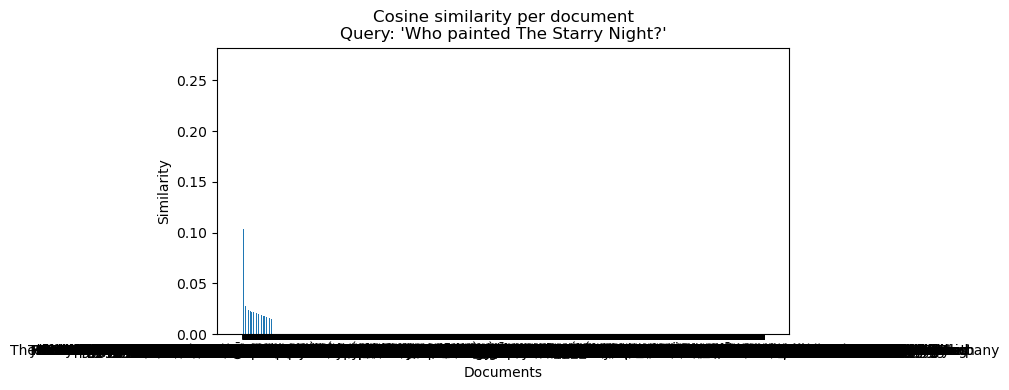

In [12]:
# Now, let's visualize scores for one query
import matplotlib.pyplot as plt

# Suppose we have a query from the user: "Who painted The Starry Night?"
q = "Who painted The Starry Night?"
topk = search_corpus(q, k=len(CORPUS))
labels = [item['title'] for item in topk]
vals = [item['score'] for item in topk]

plt.figure(figsize=(10, 4))
plt.bar(labels, vals, width=0.5)
plt.title("Cosine similarity per document\nQuery: 'Who painted The Starry Night?'")
plt.xlabel("Documents")
plt.ylabel("Similarity")
plt.tight_layout()
plt.show()

# Step 2: Designing Prompting Techniques

We will build ReAct prompting, which extends that idea by mixing the model's written thoughts with actions.

- Recall that the agent model follows a loop (Thought → Action → Observation) where it first using chain-of-thought prompting about what to do, then takes an action, reads the result, and repeats until it is ready to answer.
- We will define a prompting format that explicitly concatnate Thought, Action, Observation into a prompt:

In [13]:
from prompting_techniques import parse_action, make_prompt

Let's do some quick tests about the functions we write


In [20]:
import json

samples = [
    'Action: yelp_search[location="Boston", term="pizza", k=3]',
    'Action: finish[answer="Regina Pizzeria is highly rated."]',
    'Action: yelp_details[business_id="abcd1234"]',
]

print("### Parsing Yelp Actions ###")
for line in samples:
    parsed = parse_action(line)
    print(f"{line}\n -> {parsed}\n")

print("Invalid line parse:", parse_action("Action: ???"))
print("\n")


# --- Building a Yelp-style trajectory ---
trajectory = [
    {
        "thought": "I should search Yelp for the highest-rated pizza spots in Boston.",
        "action": 'yelp_search[location="Boston", term="pizza", k=3]',
        "observation": json.dumps({
            "results": [
                {"name": "Regina Pizzeria", "rating": 4.7, "review_count": 2891},
                {"name": "Santarpio’s Pizza", "rating": 4.6, "review_count": 1982},
                {"name": "Picco", "rating": 4.5, "review_count": 1350}
            ]
        })
    },
    {
        "thought": "I now have enough Yelp data to answer.",
        "action": 'finish[answer="Regina Pizzeria, Santarpio’s Pizza, and Picco are top-rated."]',
        "observation": "done"
    }
]

prompt = make_prompt("What are the best pizza places in Boston?", trajectory)

# Show the last few lines so you can confirm the format cue ends with 'Thought:'
print("\n--- Prompt ---")
print("\n".join(prompt.splitlines()[-12:]))

### Parsing Yelp Actions ###
Action: yelp_search[location="Boston", term="pizza", k=3]
 -> ('yelp_search', {'location': 'Boston', 'term': 'pizza', 'k': 3})

Action: finish[answer="Regina Pizzeria is highly rated."]
 -> ('finish', {'answer': 'Regina Pizzeria is highly rated.'})

Action: yelp_details[business_id="abcd1234"]
 -> ('yelp_details', {'business_id': 'abcd1234'})

Invalid line parse: None



--- Prompt ---
Action: <one of the tool calls above, or finish[...]>

User Question: What are the best pizza places in Boston?

Thought: I should search Yelp for the highest-rated pizza spots in Boston.
Action: yelp_search[location="Boston", term="pizza", k=3]
Observation: {"results": [{"name": "Regina Pizzeria", "rating": 4.7, "review_count": 2891}, {"name": "Santarpio\u2019s Pizza", "rating": 4.6, "review_count": 1982}, {"name": "Picco", "rating": 4.5, "review_count": 1350}]}
Thought: I now have enough Yelp data to answer.
Action: finish[answer="Regina Pizzeria, Santarpio’s Pizza, and Pic

# Step 3: Building a Language Model Interface

Next, we will load a language model as the base model for the agent system. We will define the interaction between the language model and the knowledge base/external tools, using the above prompting format.

In this step, we will complete the following implementations
- We will load a GPT-style model from the Huggingface website, which stores many open-source language models. We will use a small pretrained language model as the base for our agent system.
- We will use the language model and the prompt format designed above to generate thoughts and actions for the task.


Specifically, given a user prompt, the language model is expected to return exactly the two lines:
```
Thought: …

Action: search[query="..."] or Action: finish[answer="..."]
```
With this, we can integrate our language model with the tools to solve a task



In [21]:
from language_model import LLM

Let's do a test of the LLM that we define

In [22]:
# We will use a toy
example_user_query = "What is the highest rated restraunt in new york city?"
prompt = make_prompt(example_user_query, trajectory = [])

# Let's use the LLM to generate some output
example_output = LLM(prompt)
print("====== Output of the LLM ======")
print(example_output)

/Users/niambashambu/anaconda3/envs/ds/lib/python3.12/site-packages/transformers/pytorch_utils.py:339: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_elements = torch.tensor(test_elements)


====== Output of the LLM ======
Thought: I need to search for the highest rated restaurant in New York City.
Action: search[query='highest rated restaurant in new york city', k=100]


# Step 4: Integrating Components into an Agent System
Finally, we will put everything together as an agent system, including the external database, the information search tools, and a base language model.
- The agent will take the input and use a language model to output the Thought and Action.
- The agent will execute the Action (which in this case is searching for a document) and concatenate the returned document as Observation to the next round of the prompt
- The agent will iterate over the above two steps until it identifies the answer or reaches an iteration limit.



In [23]:
from agent_system import ReActAgent, AgentConfig

# Demo Run

Finally, we will launch the system for a user query “Who painted The Starry Night and where was it painted?”

In [24]:
# ----------------------------
# Demo Run (Yelp Version)
# ----------------------------
from typing import Callable, Dict, List, Tuple, Optional, Any

agent = ReActAgent(LLM, TOOLS, AgentConfig(max_steps=6, verbose=True))

# Changed question ✓
demo_q = "What are the top rated pizza places in Boston according to Yelp?"
result = agent.run(demo_q)

print("Question:", result["question"])
print("\nFinal Answer:", result["final_answer"])
print("\nTrajectory:")
for i, s in enumerate(result["steps"], 1):
    print(f"\nStep {i}")
    print("Thought:", s["thought"])
    print("Action:", s["action"])
    print("Observation:", s["observation"][:500] + ("..." if len(s["observation"])>500 else ""))


# ----------------------------
# Tiny Evaluation Harness (Yelp Version)
# ----------------------------

# Replace gold answers with Yelp-style expected phrases ✓
GOLD = {
    "What are the top rated pizza places in Boston according to Yelp?": [
        "regina", "santarpio", "picco"  # example Yelp top spots
    ],
    "State the Pythagorean theorem.": [
        "a^2 + b^2 = c^2",
        "square of the hypotenuse equals the sum of the squares",
    ],
}

def normalize(s: str) -> str:
    return (s or "").lower()

def em_contains(pred: Optional[str], gold_phrases: List[str]) -> bool:
    p = normalize(pred)
    # must contain *all* provided substrings (unchanged logic)
    return all(g in p for g in map(normalize, gold_phrases))

def evaluate(agent: ReActAgent, questions: List[str]) -> Dict[str, Any]:
    rows = []
    for q in questions:
        out = agent.run(q)
        pred = out["final_answer"]
        gold_phrases = GOLD.get(q, [])
        ok = em_contains(pred, gold_phrases) if gold_phrases else (pred is not None)
        rows.append({"question": q, "pred": pred, "ok": ok})
    acc = sum(r["ok"] for r in rows) / max(1, len(rows))
    return {"accuracy": acc, "rows": rows}

eval_out = evaluate(agent, list(GOLD.keys()))
print("\n\nEvaluation (toy):", eval_out["accuracy"])
for r in eval_out["rows"]:
    print("-", r)


Question: What are the top rated pizza places in Boston according to Yelp?

Final Answer: None

Trajectory:

Step 1
Thought: Boston is a city in Massachusetts, USA. Yelp is a website that provides reviews and ratings of restaurants and other businesses.
Action: Action: search[query='top-rated pizza places in Boston', k=5]
Observation: {"tool": "search", "query": "top-rated pizza places in Boston", "results": [{"id": "XtJoVFG9YAVxwccgpJ-gZg", "title": "Places & Spaces For Growth Learning Center", "snippet": "6041 Drexel Rd Philadelphia PA 19131 39.9891164 -75.247701 3.0 5 1 None Local Services, Child Care & Day Care {'Monday': '6:30-18:0', 'Tuesday': '6:30-18:0', 'Wednesday': '6:30-18:0', 'Thursday': '6:30-18:0', 'Friday': '6:30-18:0'}"}, {"id": "O0YHVrUtxbsEhQ4qaWkVaw", "title": "Boston Pizza", "snippet": "10115 Princess Eliz...

Step 2
Thought: The top-rated pizza places in Boston according to Yelp are: Places & Spaces For Growth Learning Center, Boston Pizza, Fresh Places Real Estate

# Congratulations!

You’ve completed a working demo of an AI agent powered by a GPT-style language model—great job!

Next, consider how to extend this framework with additional capabilities (e.g., richer tools, better retrieval, stronger evaluation, and safety checks). We’ve outlined several concrete directions and resources in the [google doc handout](https://docs.google.com/document/d/1kzaK1K4g8QvxT3sRAVjg7xEXnD5b59NpkbOFBsEZXXk/edit?usp=sharing); see the “Further Development” section for links and examples. Explore, iterate, and have fun!